# Telemetry-traced single-G playfield tour

The robot tours the colored playfield targets. **Every leg is ONE firmware `G`
command** — the host reads the robot's pose from **telemetry** (a `SNAP` frame),
computes the robot-relative offset to the next target, and sends a single
`G <fwd_mm> <left_mm> <speed>`. The *firmware* does the driving; the host only
issues one G per hop and listens. **The plotted path is traced entirely from the
telemetry that comes back.**

One **fixed target list** is planned up front (`plan_targets`) and driven by
**both** runs, so they hit **exactly the same points** — only the telemetry
path between points differs:

1. **Simulation** — the in-process firmware sim. With bench mode on, the sim's
   `MockHAL` swaps to the **same firmware `BenchOtosSensor`** the robot runs on
   the bench, integrating commanded wheel velocity; the EKF fuses it and reports
   the pose in SNAP.
2. **Bench** — a real robot up on a stand with `DBG OTOS BENCH 1`: the Bench OTOS
   device synthesizes the pose, the wheels physically spin ("driving in its
   dream") to generate the encoder ticks fed back, and SNAP reports that pose.

Shared logic lives in `playfield_tour_drive.py` — the *exact same single-G
control path and the same `BenchOtosSensor`* run in both.

In [1]:
%matplotlib inline
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")
import subprocess, pathlib, sys

CWD = pathlib.Path.cwd()
REPO = CWD
while not (REPO / "host_tests").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
bd = REPO / "host_tests" / "build"
# RECONFIGURE then build. The reconfigure (cmake -S -B) re-globs sources and
# guarantees the C++ (incl. the MockHAL Bench-OTOS wiring) is recompiled — a
# bare `cmake --build` can leave a STALE lib that silently freezes the sim robot
# at the origin (old MockHAL + OTOS fusion on => EKF dragged to 0).
print("Building libfirmware_host (reconfigure + build)..."); sys.stdout.flush()
subprocess.run(["cmake", "-S", str(REPO / "host_tests"), "-B", str(bd)], cwd=REPO, check=True)
subprocess.run(["cmake", "--build", str(bd), "--", "-j4"], cwd=REPO, check=True)
print("Build OK")

sys.path.insert(0, str(REPO / "host_tests" / "playfield_tour"))
import importlib, playfield_tour_drive as tour
importlib.reload(tour)

ITERS, SEED, SPEED = 10, 7, 200
SERIAL_PORT = "/dev/cu.usbmodem2121102"
RUN_BENCH = True   # set True (robot on its stand) to also run Run 2 on hardware

# Plan ONE fixed target list; both runs drive these exact same points.
TARGETS = tour.plan_targets(iters=ITERS, seed=SEED)
print("tour targets (color, x_cm, y_cm):")
for i, (c, x, y) in enumerate(TARGETS, 1):
    print(f"  {i:2d}. {c:8s} ({x:+d},{y:+d})")

Building libfirmware_host (reconfigure + build)...
-- Configuring done (0.1s)
-- Generating done (0.0s)
-- Build files have been written to: /Volumes/Proj/proj/RobotProjects/radio-robot-c/host_tests/build
[100%] Built target firmware_host
Build OK
tour targets (color, x_cm, y_cm):
   1. blue     (-35,-24)
   2. purple   (-35,+24)
   3. orange   (+35,+24)
   4. blue     (-50,+0)
   5. orange   (-50,+30)
   6. black    (+0,+24)
   7. green    (+35,-24)
   8. yellow   (+0,-30)
   9. red      (+50,+0)
  10. blue     (-50,+0)


## Run 1 — Simulation
In-process firmware sim, driving `TARGETS`. Always available (no robot needed).
Raises a clear error if the sim lib is stale (robot frozen at the origin).

[ 1] (   +0,   +0) -> blue     (-35,-24)   52 pts  end=(  -33,  -23)  err=  20mm
[ 2] (  -34,  -23) -> purple   (-35,+24)   54 pts  end=(  -35,  +22)  err=  16mm
[ 3] (  -35,  +23) -> orange   (+35,+24)   68 pts  end=(  +33,  +24)  err=  17mm
[ 4] (  +34,  +24) -> blue     (-50,+0)   87 pts  end=(  -49,   +0)  err=  13mm
[ 5] (  -49,   +0) -> orange   (-50,+30)   39 pts  end=(  -50,  +28)  err=  20mm
[ 6] (  -50,  +28) -> black    (+0,+24)   54 pts  end=(   -1,  +24)  err=  12mm
[ 7] (   -1,  +24) -> green    (+35,-24)   56 pts  end=(  +34,  -22)  err=  17mm
[ 8] (  +34,  -23) -> yellow   (+0,-30)   43 pts  end=(   +2,  -30)  err=  18mm
[ 9] (   +2,  -30) -> red      (+50,+0)   64 pts  end=(  +48,   -1)  err=  17mm
[10] (  +49,   -1) -> blue     (-50,+0)   94 pts  end=(  -48,   +0)  err=  18mm

SIM: 10/10 legs arrived within 60mm


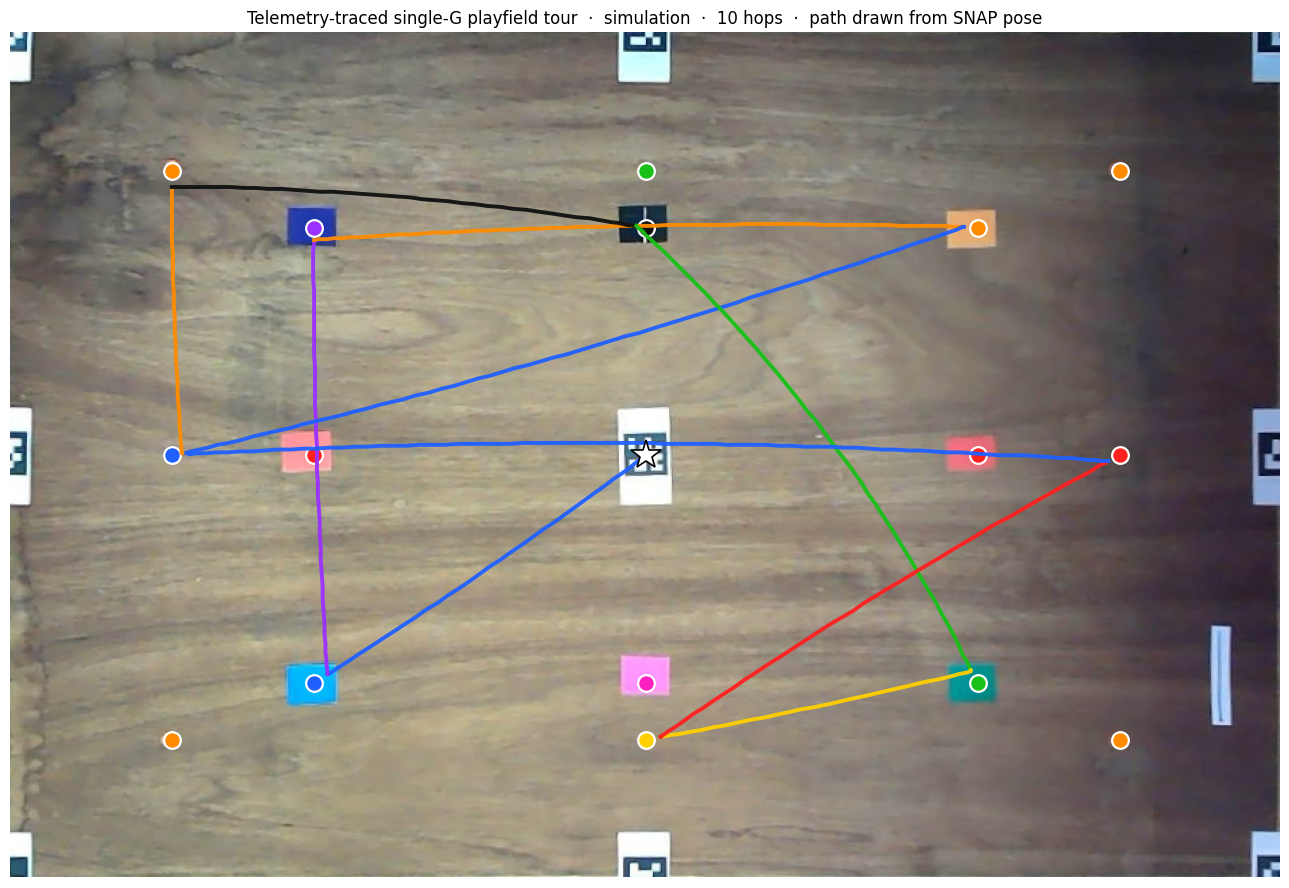

In [2]:
be = tour.SimBackend()
try:
    sim_segments = tour.run_tour(be, TARGETS, speed=SPEED)
finally:
    be.close()
print(f"\nSIM: {sum(1 for *_, e in sim_segments if e <= 60)}/{len(sim_segments)} legs arrived within 60mm")
tour.plot_tour(sim_segments, show=True, mode_label="simulation");

## Run 2 — Bench (real robot on a stand)
Set `RUN_BENCH = True` above, robot on a stand. Same `TARGETS`; `DBG OTOS BENCH 1`
engaged so the Bench OTOS device synthesizes the pose and the wheels spin to
generate the encoder ticks. Watch the wheels move as it tours.

[ 1] (   +0,   +0) -> blue     (-35,-24)   13 pts  end=(  -33,  -23)  err=  19mm
[ 2] (  -34,  -23) -> purple   (-35,+24)   11 pts  end=(  -35,  +22)  err=  16mm
[ 3] (  -35,  +23) -> orange   (+35,+24)   17 pts  end=(  +33,  +24)  err=  19mm
[ 4] (  +34,  +24) -> blue     (-50,+0)   20 pts  end=(  -49,   +0)  err=  12mm
[ 5] (  -49,   +0) -> orange   (-50,+30)    8 pts  end=(  -50,  +29)  err=  14mm
[ 6] (  -50,  +29) -> black    (+0,+24)   14 pts  end=(   -2,  +24)  err=  15mm
[ 7] (   -1,  +24) -> green    (+35,-24)   13 pts  end=(  +34,  -22)  err=  19mm
[ 8] (  +34,  -22) -> yellow   (+0,-30)    9 pts  end=(   +1,  -30)  err=  14mm
[ 9] (   +1,  -30) -> red      (+50,+0)   16 pts  end=(  +50,   -0)  err=   6mm
[10] (  +50,   +0) -> blue     (-50,+0)   20 pts  end=(  -48,   +0)  err=  19mm

BENCH: 10/10 legs arrived within 60mm


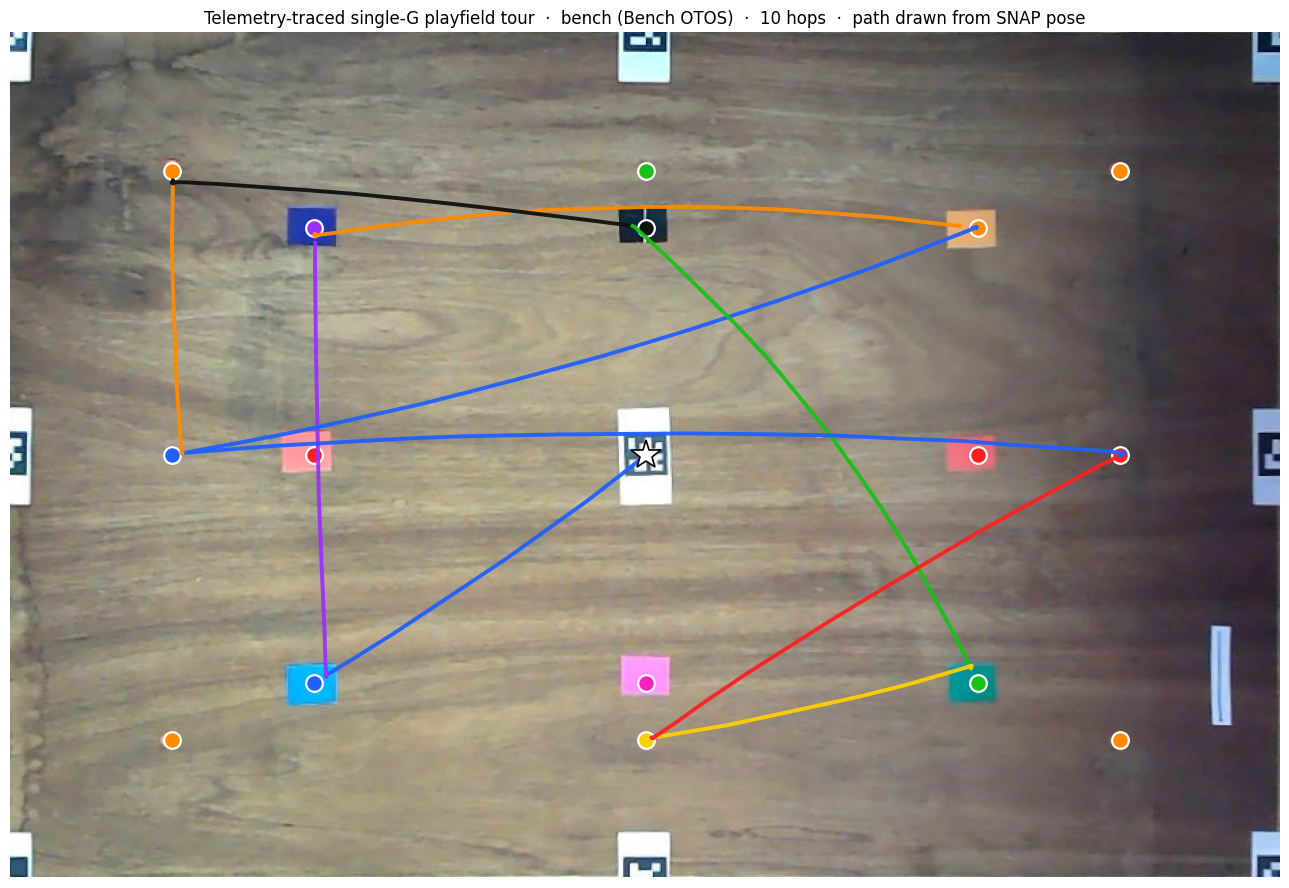

In [3]:
bench_segments = []
if not RUN_BENCH:
    print("RUN_BENCH = False -> skipping the bench run (set it True with the robot connected).")
else:
    try:
        be = tour.SerialBackend(SERIAL_PORT)
    except Exception as exc:
        print(f"No robot on {SERIAL_PORT} ({exc}). Plug in the robot (on its stand) and re-run.")
    else:
        try:
            bench_segments = tour.run_tour(be, TARGETS, speed=SPEED)
        finally:
            be.close()
        print(f"\nBENCH: {sum(1 for *_, e in bench_segments if e <= 60)}/{len(bench_segments)} legs arrived within 60mm")
        tour.plot_tour(bench_segments, show=True, mode_label="bench (Bench OTOS)");